In [14]:
# ==========================================
# 1. Data Loading
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/ML/train.csv")

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,experience,country,education,languages,frameworks,company_size,salary_usd
0,34.0,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292
1,9.0,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311
2,8.0,USA,Some College,"C++, Go","Vue, React",5000+,109637
3,29.0,USA,Masters,"C++, Ruby","Spring, Angular",Nov-50,214386
4,7.0,USA,Bachelors,"C#, Rust","React, Express",10-Jan,107584


In [15]:
# ==========================================
# 2. Preprocessing
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Remove missing values
df = df.dropna()

# Convert salary_usd into classification target
median_salary = df['salary_usd'].median()

df['salary_category'] = df['salary_usd'].apply(
    lambda x: 1 if x > median_salary else 0
)

# Features and target
X = df.drop(['salary_usd', 'salary_category'], axis=1)
y = df['salary_category']

categorical_features = ['country', 'education', 'languages', 'frameworks', 'company_size']
numeric_features = ['experience']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Encoding and scaling
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

In [16]:
# ==========================================
# 3. Logistic Regression Model Training
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

print("Logistic Regression model training completed.")

Logistic Regression model training completed.


In [17]:
# ==========================================
# 4. Generating Evaluation Metrics
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("AUC      :", auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Salary', 'High Salary']))

Accuracy : 0.8784107228338918
Precision: 0.8820116054158608
Recall   : 0.8735632183908046
F1-score : 0.87776708373436
AUC      : 0.9611541916442099

Classification Report:
              precision    recall  f1-score   support

  Low Salary       0.87      0.88      0.88      1045
 High Salary       0.88      0.87      0.88      1044

    accuracy                           0.88      2089
   macro avg       0.88      0.88      0.88      2089
weighted avg       0.88      0.88      0.88      2089



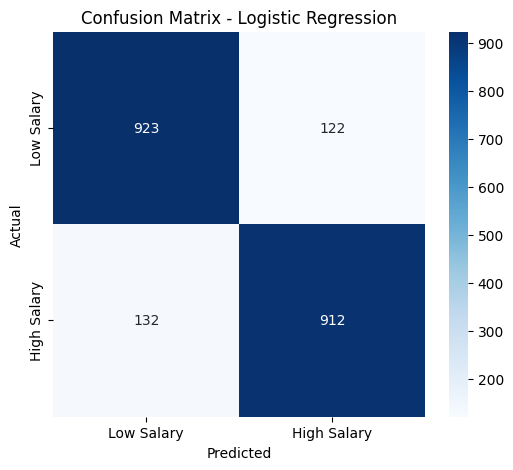

In [18]:
# ==========================================
# 5. Confusion Matrix Heatmap
# ==========================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low Salary', 'High Salary'],
    yticklabels=['Low Salary', 'High Salary']
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
# ==========================================
# 6. Evaluation Metrics Display
# ==========================================

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC'],
    'Score': [accuracy, precision, recall, f1, auc]
})

metrics_df

,Metric,Score
0,Accuracy,0.878411
1,Precision,0.882012
2,Recall,0.873563
3,F1-score,0.877767
4,AUC,0.961154


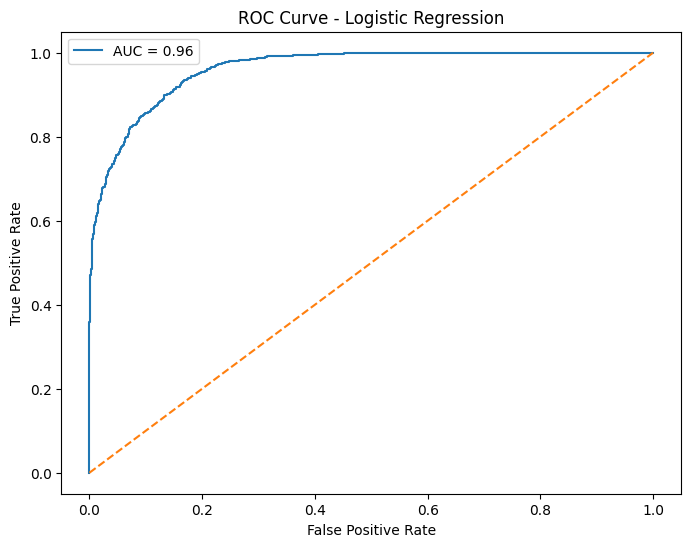

In [20]:
# ==========================================
# 7. ROC Curve
# ==========================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [21]:
# ==========================================
# 8. Sample Predictions
# Actual vs Predicted + Probability Scores
# ==========================================

sample_predictions = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'High Salary Probability': y_prob
})

sample_predictions['Actual Label'] = sample_predictions['Actual'].map({
    0: 'Low Salary',
    1: 'High Salary'
})

sample_predictions['Predicted Label'] = sample_predictions['Predicted'].map({
    0: 'Low Salary',
    1: 'High Salary'
})

sample_predictions = sample_predictions[
    ['Actual Label', 'Predicted Label', 'High Salary Probability']
]

sample_predictions.head(15)

,Actual Label,Predicted Label,High Salary Probability
0,High Salary,High Salary,0.992587
1,Low Salary,Low Salary,0.015472
2,High Salary,High Salary,0.999148
3,High Salary,High Salary,0.984164
4,Low Salary,High Salary,0.599556
5,Low Salary,Low Salary,0.016216
6,High Salary,Low Salary,0.311760
7,Low Salary,Low Salary,0.134995
8,Low Salary,Low Salary,0.000092
9,High Salary,High Salary,0.990020


In [ ]:
# Conclusion:
# The Logistic Regression model was successfully implemented on the Software Developer Salary Prediction dataset.
# Since Logistic Regression is used for classification, salary_usd was converted into two categories: Low Salary and High Salary.
# Data preprocessing, categorical encoding, feature selection, and model training were performed.
# The model classified salary category based on experience, country, education, languages, frameworks, and company_size.
# The model performance was evaluated using Accuracy, Confusion Matrix, Precision, Recall, and F1-Score.